# Step 1: Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Step 2: Import libraries

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Step 3: Dataset path

In [3]:
base_dir = "/content/drive/MyDrive/Classroom/8DCSE.2 - CSE 443 - Neural Net/Assignment/Problem_Set_01/Archive"

train_dir = base_dir + "/train"
val_dir = base_dir + "/val"
test_dir = base_dir + "/test"

# Step 4: Data Generators

In [4]:
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir, target_size=(150,150), batch_size=32, class_mode='binary'
)

val_data = val_datagen.flow_from_directory(
    val_dir, target_size=(150,150), batch_size=32, class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    test_dir, target_size=(150,150), batch_size=32, class_mode='binary'
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


# Step 5: Model

In [5]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Step 6: Compile

In [6]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Step 7: Train

In [7]:
history = model.fit(train_data, validation_data=val_data, epochs=5)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 1103s 7s/step - accuracy: 0.8875 - loss: 0.2818 - val_accuracy: 0.7500 - val_loss: 0.3737
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 67s 412ms/step - accuracy: 0.9668 - loss: 0.0932 - val_accuracy: 0.8125 - val_loss: 0.2553
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 66s 407ms/step - accuracy: 0.9716 - loss: 0.0812 - val_accuracy: 0.9375 - val_loss: 0.1628
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 68s 414ms/step - accuracy: 0.9755 - loss: 0.0702 - val_accuracy: 0.9375 - val_loss: 0.1326
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 70s 429ms/step - accuracy: 0.9783 - loss: 0.0604 - val_accuracy: 0.8750 - val_loss: 0.2400


# Step 8: Evaluate

In [8]:
loss, acc = model.evaluate(test_data)
print("Test Accuracy:", acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 160s 8s/step - accuracy: 0.7372 - loss: 1.2610
Test Accuracy: 0.7371794581413269


# Step 9: Predictions

In [9]:
test_data.reset()
y_pred = model.predict(test_data)
y_pred = (y_pred > 0.5).astype(int).flatten()

y_true = test_data.classes

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 340ms/step


# Step 10: Confusion Matrix

In [10]:
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[ 31 203]
 [ 43 347]]


# Step 11: Classification Report

In [11]:
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=["Normal", "Pneumonia"]))

Classification Report:

              precision    recall  f1-score   support

      Normal       0.42      0.13      0.20       234
   Pneumonia       0.63      0.89      0.74       390

    accuracy                           0.61       624
   macro avg       0.52      0.51      0.47       624
weighted avg       0.55      0.61      0.54       624



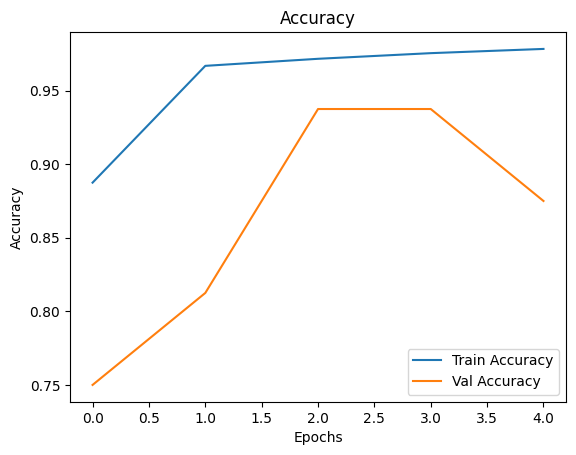

In [12]:
# Accuracy Graph
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

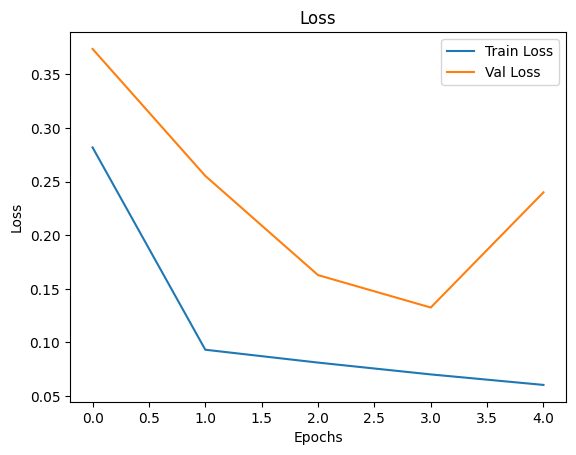

In [13]:
# Loss Graph
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()